### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **name**: Aaron Zeng
*   Your **student number**: 1008222488
 


## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [2]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

raw_data

,entity,code,year,population_historical
0,Afghanistan,AFG,-10000,14737
1,Afghanistan,AFG,-9000,20405
2,Afghanistan,AFG,-8000,28253
3,Afghanistan,AFG,-7000,39120
4,Afghanistan,AFG,-6000,54166
...,...,...,...,...
58819,Zimbabwe,ZWE,2019,15271377
58820,Zimbabwe,ZWE,2020,15526887
58821,Zimbabwe,ZWE,2021,15797220
58822,Zimbabwe,ZWE,2022,16069061


In [6]:
# collecting the countries
countries_df = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        countries_list_url,
        headers=headers).text),
    index_col=False)

# changing the name of the column to Countries
countries_df = countries_df.rename(mapper = {"Afghanistan": "Countries"}, axis = "columns")

# adding Afghanistan back to the list of countries
countries_df = pd.concat([pd.DataFrame({"Countries":["Afghanistan"]}), countries_df], ignore_index = True)
countries_df

countries_df

,Countries
0,Afghanistan
1,Albania
2,Algeria
3,American Samoa
4,Andorra
...,...
232,Wallis and Futuna
233,Western Sahara
234,Yemen
235,Zambia


In [ ]:
# collecting the year data for only the countries on the list
year_data_df = pd.DataFrame()
for country in range(len(countries_df["Countries"])):
    year_data_df = pd.concat([year_data_df, raw_data[raw_data["entity"] == countries_df["Countries"][country]]])

year_data_df

,entity,code,year,population_historical
0,Afghanistan,AFG,-10000,14737
1,Afghanistan,AFG,-9000,20405
2,Afghanistan,AFG,-8000,28253
3,Afghanistan,AFG,-7000,39120
4,Afghanistan,AFG,-6000,54166
...,...,...,...,...
58819,Zimbabwe,ZWE,2019,15271377
58820,Zimbabwe,ZWE,2020,15526887
58821,Zimbabwe,ZWE,2021,15797220
58822,Zimbabwe,ZWE,2022,16069061


In [9]:
# generating the list of years of interest
year_list = [year for year in range(1901, 2024)]

In [ ]:
# collecting the years for the countries of interest
year_data_of_interest_df = pd.DataFrame()
for year in year_list:
    year_data_of_interest_df = pd.concat([year_data_of_interest_df, year_data_df[year_data_df["year"] == year]])

year_data_of_interest_df

,entity,code,year,population_historical
138,Afghanistan,AFG,1901,4751177
737,Albania,ALB,1901,813539
998,Algeria,DZA,1901,4787149
1449,Andorra,AND,1901,4551
1710,Angola,AGO,1901,3083888
...,...,...,...,...
57533,Wallis and Futuna,WLF,2023,11394
57656,Western Sahara,ESH,2023,579734
58178,Yemen,YEM,2023,39390800
58562,Zambia,ZMB,2023,20723967


In [ ]:
# collecting the population data for each year and each country of interest as long as there are valid entries for every year for that particular country

year_population_dict = {}

for year in year_list:
    for country in countries_year_data_dict.keys():
        if year not in year_population_dict:
            # checks to see if the total of the years of the year data available for a country is equal to the sum of all the years from 1901 - 2023 inclusive
            # if these numbers are the same then this country has valid entries for all of these years
            year_population_dict[year] = list(year_data_of_interest_df[(year_data_of_interest_df["year"] == year) & (year_data_of_interest_df["entity"] == country)]["population_historical"])
        
        else:
            year_population_dict[year].extend(list(year_data_of_interest_df[(year_data_of_interest_df["year"] == year) & (year_data_of_interest_df["entity"] == country)]["population_historical"]))

In [14]:
# generating the dataframe for the countries and population data
countries_list = list(countries_year_data_dict.keys())
df = pd.DataFrame(year_population_dict, index = countries_list)

1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

In [15]:
import matplotlib.pyplot as plt

def plot_population_data(countries_population_df, countries_list_of_interest):
    fig, ax = plt.subplots(
        nrows = 1,
        ncols = len(countries_list_of_interest),
        figsize = (len(countries_list_of_interest)*4, 3))

    for country in range(len(countries_list_of_interest)):
        ax[country].plot(year_list, countries_population_df.loc[countries_list_of_interest[country]])
        ax[country].set_title(countries_list_of_interest[country])
        ax[country].set_xlabel("Year")
        ax[country].set_ylabel("Population")

    plt.tight_layout()

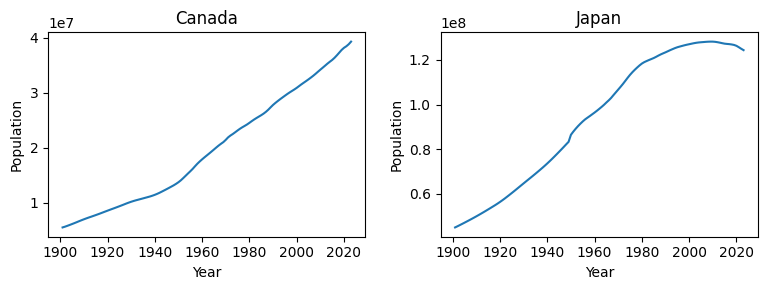

In [16]:
country_list = ["Canada", "Japan"]
plot_population_data(df, country_list)

In [ ]:
# scaling the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, index = countries_list, columns = year_list)

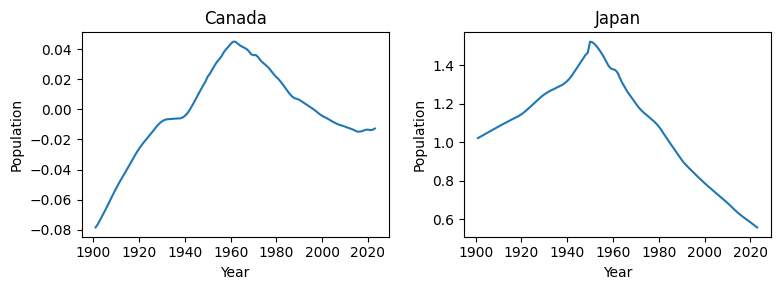

In [18]:
plot_population_data(scaled_df, country_list)

In [19]:
import Levenshtein

def calc_two_closest_countries(target, countries_list):
    
    closest_countries = [None, None]
    closest = 100
    second_closest = 100

    for country in countries_list:
        dist = Levenshtein.distance(country, target)
        
        if dist < closest:
            closest = dist
            closest_countries[0] = country
        
        elif dist < second_closest:
            second_closest = dist
            closest_countries[1] = country

    
    return closest_countries

In [ ]:
# finding the closest countries to my name
closest_countries = calc_two_closest_countries("Aaron", countries_list)
closest_countries

['Gabon', 'Iran']

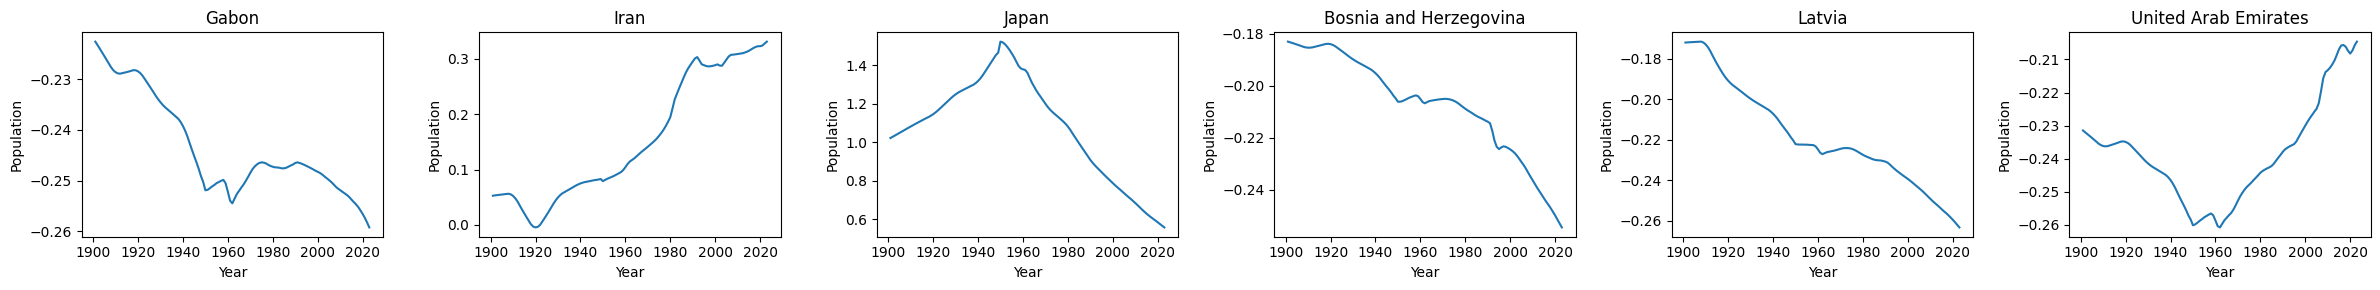

In [21]:
plot_population_data(scaled_df, ["Gabon", "Iran", "Japan",  "Bosnia and Herzegovina", "Latvia", "United Arab Emirates"])

If the curve goes up for a particular, it means that relative to all other countries, this country's population is increasing faster and decreasing if the curve does down. The magnitude of the values indicate how far away from the average, the country's population is and the sign indicate the direction where more negative numbers are smaller than the global average